# Audio-Based Heart Murmur Detection From Mel Spectrograms Using CNN, LSTM, and CNN-LSTM Models
## AI in Healthcare Self-Learning Tutorial
### Preprocess Data

In [5]:
# Import libraries
from collections import Counter
import joblib
import librosa
import matplotlib.pyplot as plt
import numpy as np
import os
import pandas as pd
import random
from sklearn.metrics import f1_score, precision_score, recall_score, roc_auc_score
from sklearn.model_selection import train_test_split
from sklearn.utils import shuffle
import soundfile as sf
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from tqdm.notebook import tqdm
import xgboost as xgb

random.seed(2025)


In [2]:
# Get Mel Spectrogram from a .wav file
def augment_audio(y, sr):
    if np.random.rand() > 0.1:
        y = librosa.effects.time_stretch(y, rate=np.random.uniform(0.8, 1.2))
    if np.random.rand() > 0.1:
        y = librosa.effects.pitch_shift(y, sr=sr, n_steps=np.random.randint(-2, 2))
    noise = np.random.normal(0, np.random.uniform(0.002, 0.01), y.shape)
    y = y + noise
    return y

def get_mel_spectrogram(path, median_ts=-1, augment=False):
    y, sr = sf.read(path)
    if sr != 22050:
        y = librosa.resample(y, orig_sr=sr, target_sr=22050)
    if augment:
        y = augment_audio(y, sr)
    mel_spec = librosa.power_to_db(librosa.feature.melspectrogram(y=y, sr=22050, n_mels=128), ref=np.max)
    if mel_spec.shape[1] > median_ts:
        mel_spec = mel_spec[:, :median_ts]
    else:
        pad_width = median_ts - mel_spec.shape[1]
        pad_left = pad_width // 2
        pad_right = pad_width - pad_left 
        mel_spec = np.pad(mel_spec, ((0, 0), (pad_left, pad_right)), mode='constant')
        
    return mel_spec
    

In [3]:
# Get features and labels
wav_files = [f for f in os.listdir("data") if f.endswith(".wav")]
patients_df = pd.read_csv("patients.csv")

labels_dict = {}

for f in wav_files:
    patient_id = f.split("_")[0]
    loc = f.split("_")[1].split(".")[0]
    n_label = patients_df[patients_df["Patient ID"] == int(patient_id)]["Murmur"].values[0]
    murmur_locs = patients_df[patients_df["Patient ID"] == int(patient_id)]["Murmur locations"].values
    if len(murmur_locs) > 0 and isinstance(murmur_locs[0], str):
        murmur_locs = murmur_locs[0].split("+")
    else:
        murmur_locs = []

    label = 1 if n_label == "Present" and loc in murmur_locs else 0
    labels_dict[f] = label

all_ones = [f for f, label in labels_dict.items() if label == 1]
all_zeros = [f for f, label in labels_dict.items() if label == 0]

selected_zeros = random.sample(all_zeros, len(all_ones))

balanced_wav_files = all_ones + selected_zeros

median_time_steps = int(np.median([get_mel_spectrogram(os.path.join("data", f)).shape[1] for f in tqdm(balanced_wav_files, desc="Loading Data...")]))

features, labels = [], []

for f in tqdm(balanced_wav_files, desc="Extracting Features..."):
    path = os.path.join("data", f)
    patient_id = f.split("_")[0]
    loc = f.split("_")[1].split(".")[0]
    mel_spec = get_mel_spectrogram(path, median_time_steps)
    n_label = patients_df[patients_df["Patient ID"] == int(patient_id)]["Murmur"].values[0]
    murmur_locs = patients_df[patients_df["Patient ID"] == int(patient_id)]["Murmur locations"].values
    if len(murmur_locs) > 0 and isinstance(murmur_locs[0], str):
        murmur_locs = murmur_locs[0].split("+")
    else:
        murmur_locs = []
    label = 1 if n_label == "Present" and loc in murmur_locs else 0
    features.append(mel_spec)
    labels.append(label)

x = np.array(features)
y = np.array(labels)

x_train, x_test, y_train, y_test, train_paths, _ = train_test_split(x, y, balanced_wav_files, test_size=0.2, random_state=0)

augmented_features, augmented_labels = [], []

for i in tqdm(range(len(x_train)), desc="Creating Synthetic Data..."):
    path = os.path.join("data", train_paths[i])
    for _ in range(4):
        mel_spec_aug = get_mel_spectrogram(path, median_time_steps, augment=True)
        augmented_features.append(mel_spec_aug)
        augmented_labels.append(y_train[i])

x_train = np.concatenate([x_train, np.array(augmented_features)])
y_train = np.concatenate([y_train, np.array(augmented_labels)])
x_train, y_train = shuffle(x_train, y_train, random_state=0)


Loading Data...:   0%|          | 0/998 [00:00<?, ?it/s]

Extracting Features...:   0%|          | 0/998 [00:00<?, ?it/s]

Creating Synthetic Data...:   0%|          | 0/798 [00:00<?, ?it/s]

### Audio Data Exploration

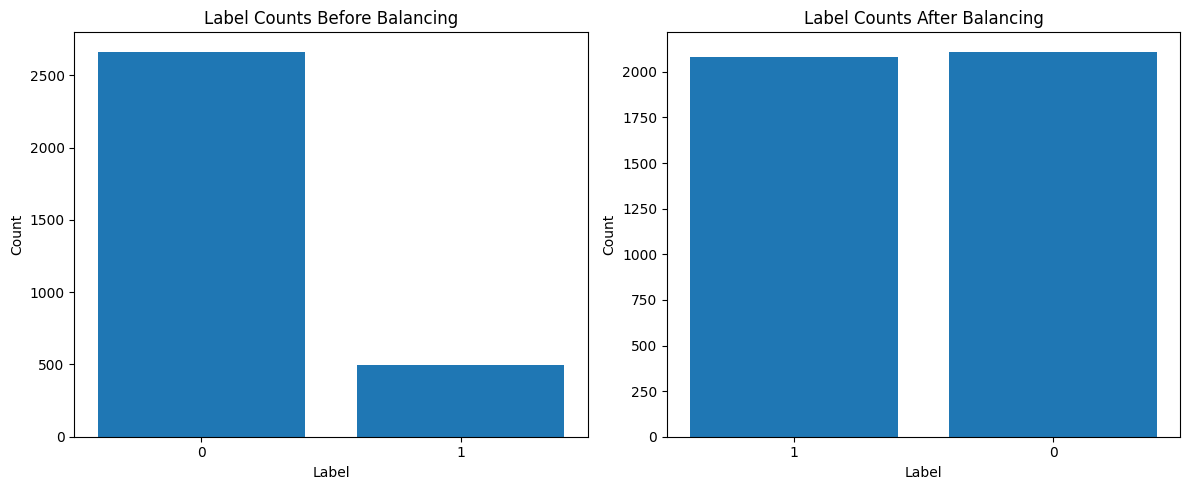

In [6]:
# Show counts of 0s and 1s
original_counts = {"0": len(all_zeros), "1": len(all_ones)}
balanced_counts = Counter(np.concatenate([y_train, y_test]))
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].bar(original_counts.keys(), original_counts.values(), tick_label=["0", "1"])
axes[0].set_title("Label Counts Before Balancing")
axes[0].set_xlabel("Label")
axes[0].set_ylabel("Count")
axes[1].bar(balanced_counts.keys(), balanced_counts.values(), tick_label=["0", "1"])
axes[1].set_title("Label Counts After Balancing")
axes[1].set_xlabel("Label")
axes[1].set_ylabel("Count")
plt.tight_layout()
plt.show()


In [7]:
# Function to plot spectrograms
def plot_spectrogram(path, title, ax, augment=None):
    y, sr = sf.read(path)
    if sr != 22050:
        y = librosa.resample(y, orig_sr=sr, target_sr=22050)
    if augment == "stretch":
        y = librosa.effects.time_stretch(y, rate=1.2)
    if augment == "shift":
        y = librosa.effects.pitch_shift(y, sr=sr, n_steps=-2)
    if augment == "noise":
        noise = np.random.normal(0, 0.01, y.shape)
        y = y + noise
    D = librosa.amplitude_to_db(np.abs(librosa.stft(y)), ref=np.max)
    librosa.display.specshow(D, sr=sr, x_axis="time", y_axis="log", ax=ax)
    ax.set_title(title)
    ax.set_xlabel("Time (s)")
    ax.set_ylabel("Frequency (Hz)")
    

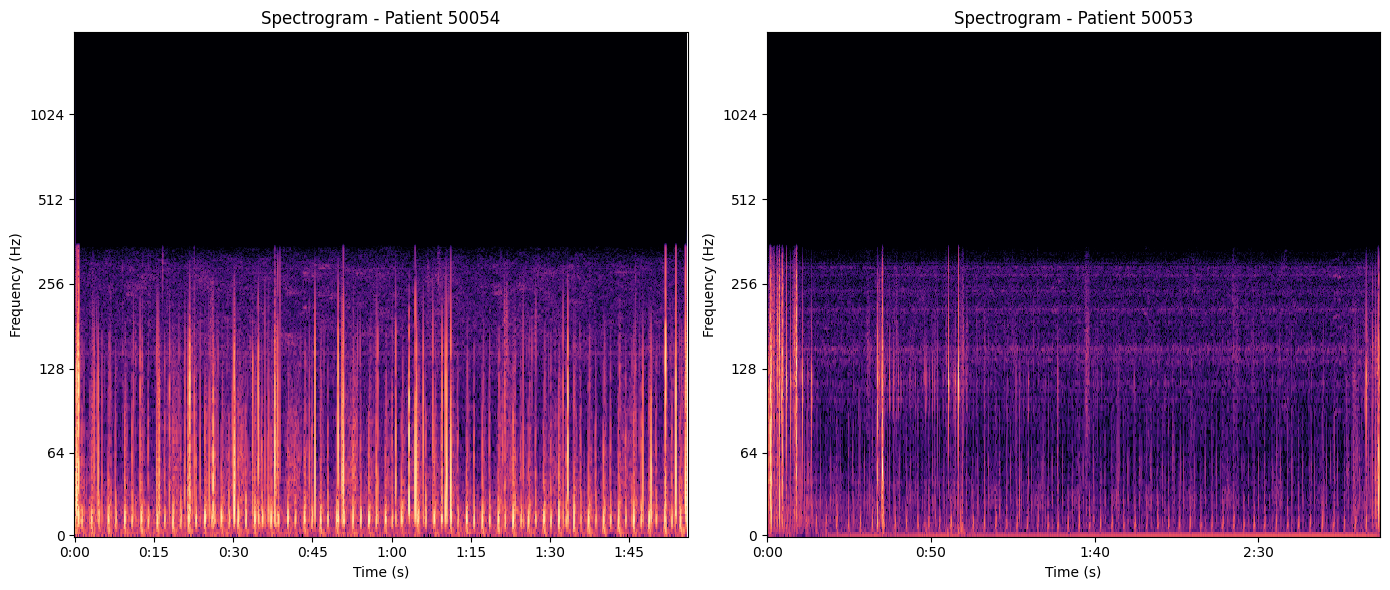

In [8]:
# Comparison of non-murmur recordings from two different patients
audio_path_50054 = "data/50054_TV.wav"
audio_path_50053 = "data/50053_TV.wav"
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
plot_spectrogram(audio_path_50054, "Spectrogram - Patient 50054", axes[0])
plot_spectrogram(audio_path_50053, "Spectrogram - Patient 50053", axes[1])
plt.tight_layout()
plt.show()


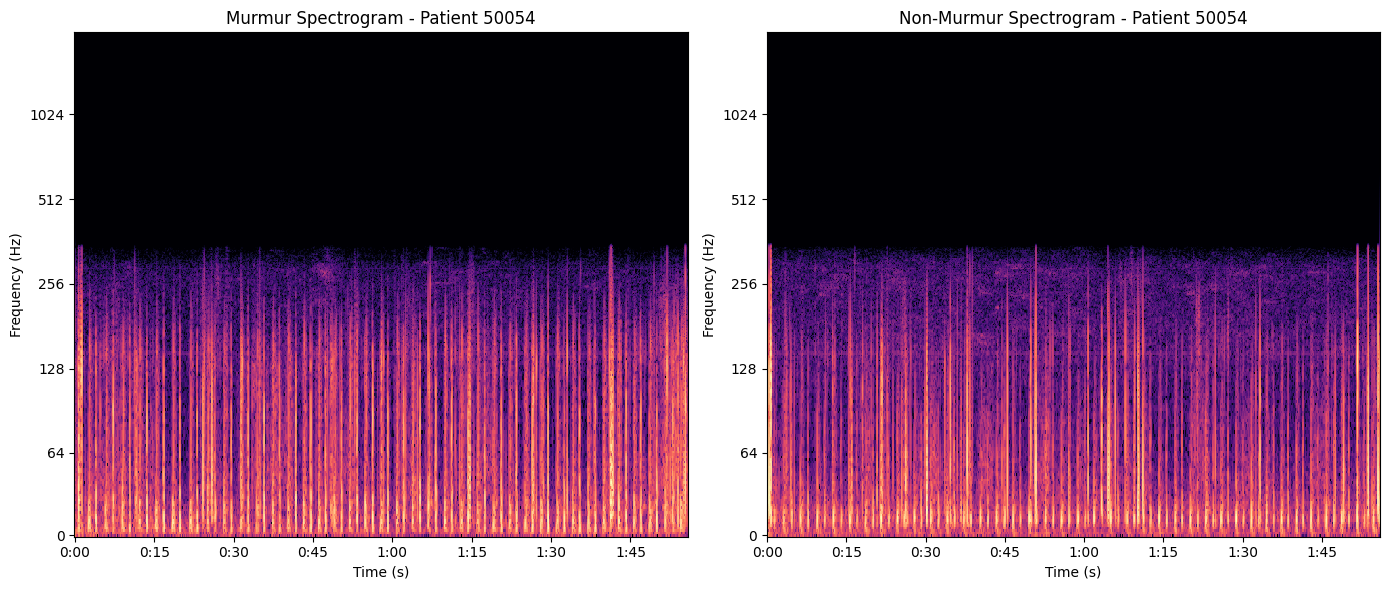

In [9]:
# Comparison of murmur and non-murmur recordings from the same patient
murmur_audio_path = "data/50054_PV.wav"
non_murmur_audio_path = "data/50054_TV.wav"
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
plot_spectrogram(murmur_audio_path, "Murmur Spectrogram - Patient 50054", axes[0])
plot_spectrogram(non_murmur_audio_path, "Non-Murmur Spectrogram - Patient 50054", axes[1])
plt.tight_layout()
plt.show()


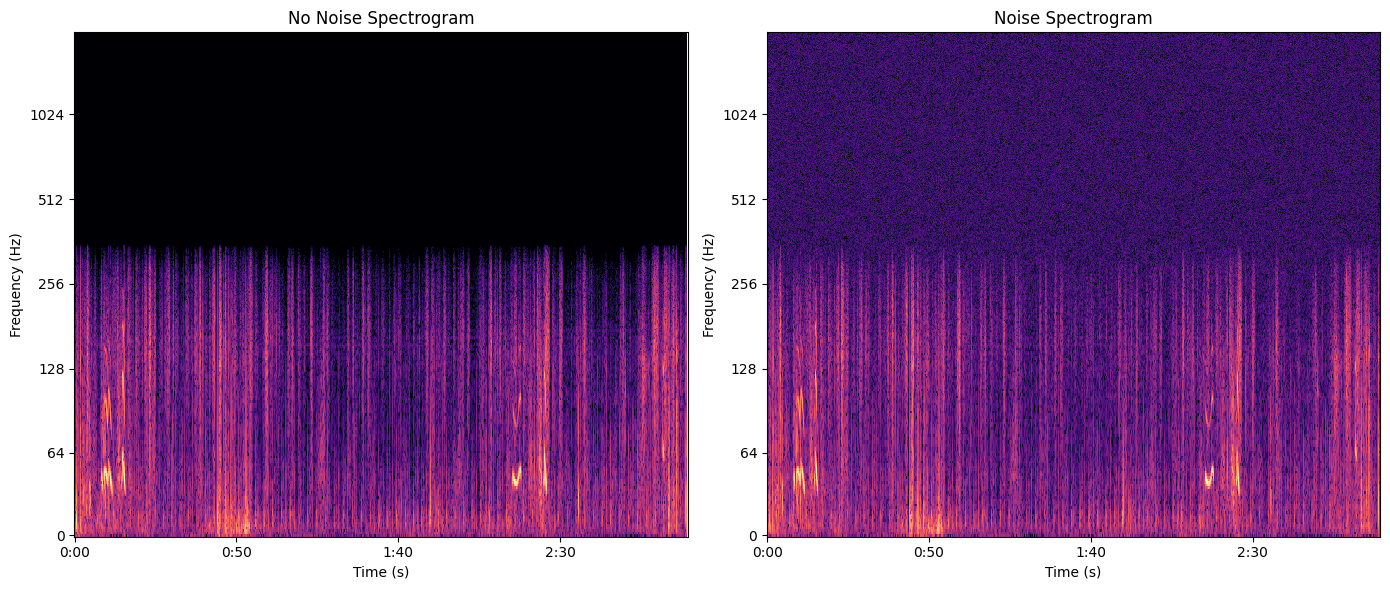

In [10]:
# Comparison of the same recording with no noise and noise
no_noise_audio_path = "data/50123_MV.wav"
noise_audio_path = "data/50123_MV.wav"
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
plot_spectrogram(no_noise_audio_path, "No Noise Spectrogram", axes[0])
plot_spectrogram(noise_audio_path, "Noise Spectrogram", axes[1], augment="noise")
plt.tight_layout()
plt.show()


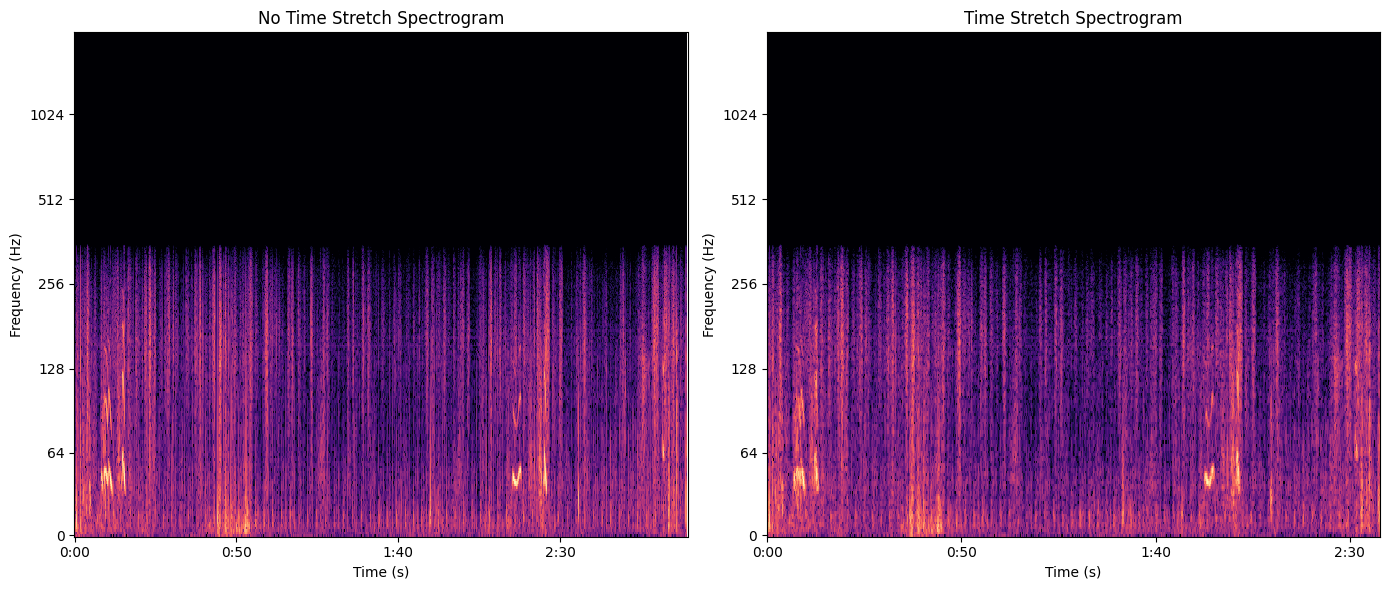

In [11]:
# Comparison of the same recording with no time stretch and time stretch
no_stretch_audio_path = "data/50123_MV.wav"
stretch_audio_path = "data/50123_MV.wav"
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
plot_spectrogram(no_stretch_audio_path, "No Time Stretch Spectrogram", axes[0])
plot_spectrogram(stretch_audio_path, "Time Stretch Spectrogram", axes[1], augment="stretch")
plt.tight_layout()
plt.show()


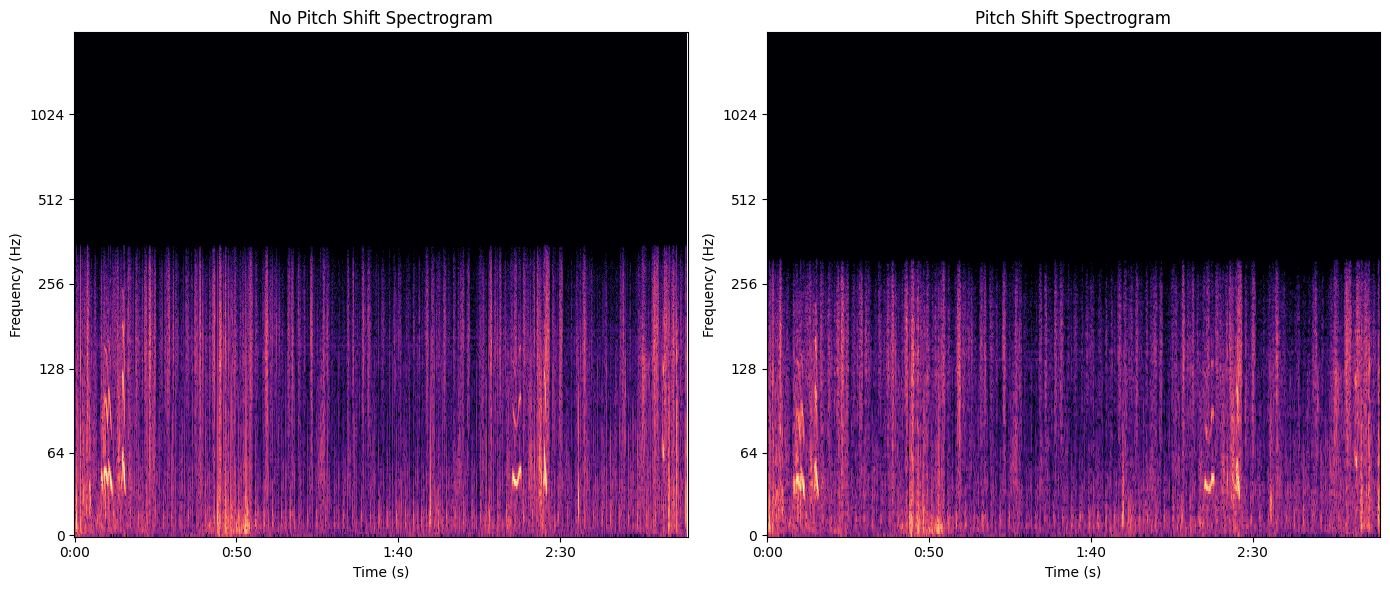

In [12]:
# Comparison of the same recording with no pitch shift and pitch shift
no_shift_audio_path = "data/50123_MV.wav"
shift_audio_path = "data/50123_MV.wav"
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
plot_spectrogram(no_shift_audio_path, "No Pitch Shift Spectrogram", axes[0])
plot_spectrogram(shift_audio_path, "Pitch Shift Spectrogram", axes[1], augment="shift")
plt.tight_layout()
plt.show()


### Build & Train the Models

In [13]:
# Create a Dataset and DataLoader for the Neural Architectures
class MurmurDataset(Dataset):
    def __init__(self, x, y):
        self.x = torch.tensor(x, dtype=torch.float32).unsqueeze(1)
        self.y = torch.tensor(y, dtype=torch.float32)

    def __len__(self):
        return len(self.x)

    def __getitem__(self, idx):
        return self.x[idx], self.y[idx]

train_dataset = MurmurDataset(x_train, y_train)
test_dataset = MurmurDataset(x_test, y_test)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)


In [14]:
# Create a CNN model
class CNN(nn.Module):
    def __init__(self):
        super(CNN, self).__init__()
        self.conv1 = nn.Conv2d(1, 32, kernel_size=3, stride=1, padding=1)
        self.bn1 = nn.BatchNorm2d(32)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, stride=1, padding=1)
        self.bn2 = nn.BatchNorm2d(64)
        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, stride=1, padding=1)
        self.bn3 = nn.BatchNorm2d(128)
        self.conv4 = nn.Conv2d(128, 256, kernel_size=3, stride=1, padding=1)
        self.bn4 = nn.BatchNorm2d(256)
        self.conv5 = nn.Conv2d(256, 512, kernel_size=3, stride=1, padding=1)
        self.bn5 = nn.BatchNorm2d(512)
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)
        self.fc1 = nn.Linear(512 * (128 // 32) * (x_train.shape[2] // 32), 1024)
        self.fc2 = nn.Linear(1024, 512)
        self.fc3 = nn.Linear(512, 128)
        self.fc4 = nn.Linear(128, 1)
        self.dropout = nn.Dropout(0.5)

    def forward(self, x):
        x = self.pool(torch.relu(self.bn1(self.conv1(x))))
        x = self.pool(torch.relu(self.bn2(self.conv2(x))))
        x = self.pool(torch.relu(self.bn3(self.conv3(x))))
        x = self.pool(torch.relu(self.bn4(self.conv4(x))))
        x = self.pool(torch.relu(self.bn5(self.conv5(x))))
        x = x.view(x.size(0), -1)
        x = torch.relu(self.fc1(x))
        x = self.dropout(x)
        x = torch.relu(self.fc2(x))
        x = self.dropout(x)
        x = torch.relu(self.fc3(x))
        x = self.dropout(x)
        return torch.sigmoid(self.fc4(x))


In [15]:
# Create a LSTM model
class LSTM(nn.Module):
    def __init__(self):
        super(LSTM, self).__init__()
        self.lstm = nn.LSTM(input_size=128, hidden_size=256, num_layers=5, batch_first=True, bidirectional=True, dropout=0.5)
        self.fc1 = nn.Linear(256 * 2, 128)
        self.fc2 = nn.Linear(128, 64)
        self.fc3 = nn.Linear(64, 1)
        self.dropout = nn.Dropout(0.5)

    def forward(self, x):
        x, _ = self.lstm(x)
        x = self.dropout(x[:, -1, :])
        x = torch.relu(self.fc1(x))
        x = self.dropout(x)
        x = torch.relu(self.fc2(x))
        x = self.dropout(x)
        return torch.sigmoid(self.fc3(x))


In [16]:
# Create CNN-LSTM model
class CNN_LSTM(nn.Module):
    def __init__(self):
        super(CNN_LSTM, self).__init__()
        self.conv1 = nn.Conv2d(1, 32, kernel_size=3, stride=1, padding=1)
        self.bn1 = nn.BatchNorm2d(32)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, stride=1, padding=1)
        self.bn2 = nn.BatchNorm2d(64)
        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, stride=1, padding=1)
        self.bn3 = nn.BatchNorm2d(128)
        self.conv4 = nn.Conv2d(128, 256, kernel_size=3, stride=1, padding=1)
        self.bn4 = nn.BatchNorm2d(256)
        self.conv5 = nn.Conv2d(256, 512, kernel_size=3, stride=1, padding=1)
        self.bn5 = nn.BatchNorm2d(512)
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)
        self.lstm = nn.LSTM(input_size=512, hidden_size=256, num_layers=3, batch_first=True, bidirectional=True)
        self.fc1 = nn.Linear(256 * 2, 128)
        self.fc2 = nn.Linear(128, 64)
        self.fc3 = nn.Linear(64, 1)
        self.dropout = nn.Dropout(0.5)

    def forward(self, x):
        batch_size = x.size(0)
        x = self.pool(torch.relu(self.bn1(self.conv1(x))))
        x = self.pool(torch.relu(self.bn2(self.conv2(x))))
        x = self.pool(torch.relu(self.bn3(self.conv3(x))))
        x = self.pool(torch.relu(self.bn4(self.conv4(x))))
        x = self.pool(torch.relu(self.bn5(self.conv5(x))))
        x = x.permute(0, 3, 1, 2).contiguous().view(batch_size, -1, 512)
        x, _ = self.lstm(x)
        x = self.dropout(x[:, -1, :])
        x = torch.relu(self.fc1(x))
        x = self.dropout(x)
        x = torch.relu(self.fc2(x))
        x = self.dropout(x)
        return torch.sigmoid(self.fc3(x))


In [17]:
# Accuracy function
def compute_accuracy(model, dataloader):
    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for batch_x, batch_y in dataloader:
            batch_x, batch_y = batch_x.to(device), batch_y.to(device)
            if isinstance(model, LSTM):
                batch_x = batch_x.squeeze(1).permute(0, 2, 1)
            outputs = model(batch_x)
            preds = (outputs.squeeze() > 0.5).float()
            correct += (preds == batch_y).sum().item()
            total += batch_y.size(0)
    return correct / total
    

In [18]:
# Train all 3 models
# Set up the models
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

cnn_model = CNN().to(device)
lstm_model = LSTM().to(device)
cnn_lstm_model = CNN_LSTM().to(device)

loss_fcn = nn.BCELoss()
optimizer_cnn = optim.Adam(cnn_model.parameters(), lr=0.00001)
optimizer_lstm = optim.Adam(lstm_model.parameters(), lr=0.00001)
optimizer_cnn_lstm = optim.Adam(cnn_lstm_model.parameters(), lr=0.00001)

metrics_columns = ["epoch", "model", "train_loss", "train_acc", "val_loss", "val_acc", "f1_score", "precision", "recall", "roc_auc"]
metrics_df = pd.DataFrame(columns=metrics_columns)

# Training loop
num_epochs = 20
for epoch in range(num_epochs):
    cnn_model.train()
    lstm_model.train()
    cnn_lstm_model.train()
    
    epoch_loss_cnn, epoch_loss_lstm, epoch_loss_cnn_lstm = 0.0, 0.0, 0.0
    correct_cnn, correct_lstm, correct_cnn_lstm, total = 0, 0, 0, 0
    
    progress_bar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs}", leave=False)

    for batch_x, batch_y in progress_bar:
        batch_x, batch_y = batch_x.to(device), batch_y.to(device)

        optimizer_cnn.zero_grad()
        outputs_cnn = cnn_model(batch_x)
        loss_cnn = loss_fcn(outputs_cnn.squeeze(), batch_y)
        loss_cnn.backward()
        optimizer_cnn.step()
        epoch_loss_cnn += loss_cnn.item()

        preds_cnn = (outputs_cnn.squeeze() > 0.5).float()
        correct_cnn += (preds_cnn == batch_y).sum().item()

        optimizer_lstm.zero_grad()
        outputs_lstm = lstm_model(batch_x.squeeze(1).permute(0, 2, 1))
        loss_lstm = loss_fcn(outputs_lstm.squeeze(), batch_y)
        loss_lstm.backward()
        optimizer_lstm.step()
        epoch_loss_lstm += loss_lstm.item()

        preds_lstm = (outputs_lstm.squeeze() > 0.5).float()
        correct_lstm += (preds_lstm == batch_y).sum().item()

        optimizer_cnn_lstm.zero_grad()
        outputs_cnn_lstm = cnn_lstm_model(batch_x)
        loss_cnn_lstm = loss_fcn(outputs_cnn_lstm.squeeze(), batch_y)
        loss_cnn_lstm.backward()
        optimizer_cnn_lstm.step()
        epoch_loss_cnn_lstm += loss_cnn_lstm.item()

        preds_cnn_lstm = (outputs_cnn_lstm.squeeze() > 0.5).float()
        correct_cnn_lstm += (preds_cnn_lstm == batch_y).sum().item()

        total += batch_y.size(0)
        progress_bar.set_postfix(loss_cnn=loss_cnn.item(), loss_lstm=loss_lstm.item(), loss_cnn_lstm=loss_cnn_lstm.item())

    # Calculate loss and accuracy metrics
    train_loss_cnn = epoch_loss_cnn / len(train_loader)
    train_acc_cnn = correct_cnn / total
    train_loss_lstm = epoch_loss_lstm / len(train_loader)
    train_acc_lstm = correct_lstm / total
    train_loss_cnn_lstm = epoch_loss_cnn_lstm / len(train_loader)
    train_acc_cnn_lstm = correct_cnn_lstm / total

    val_loss_cnn, val_loss_lstm, val_loss_cnn_lstm = 0.0, 0.0, 0.0
    val_acc_cnn = compute_accuracy(cnn_model, val_loader)
    val_acc_lstm = compute_accuracy(lstm_model, val_loader)
    val_acc_cnn_lstm = compute_accuracy(cnn_lstm_model, val_loader)
    val_preds, val_labels = {"cnn": [], "lstm": [], "cnn_lstm": []}, []

    with torch.no_grad():
        cnn_model.eval()
        lstm_model.eval()
        cnn_lstm_model.eval()
        for batch_x, batch_y in val_loader:
            batch_x, batch_y = batch_x.to(device), batch_y.to(device)
            val_labels.extend(batch_y.cpu().numpy())
            
            outputs_cnn = cnn_model(batch_x)
            loss_cnn = loss_fcn(outputs_cnn.squeeze(), batch_y)
            val_loss_cnn += loss_cnn.item()
            val_preds["cnn"].extend((outputs_cnn.squeeze() > 0.5).cpu().numpy())
            
            outputs_lstm = lstm_model(batch_x.squeeze(1).permute(0, 2, 1))
            loss_lstm = loss_fcn(outputs_lstm.squeeze(), batch_y)
            val_loss_lstm += loss_lstm.item()
            val_preds["lstm"].extend((outputs_lstm.squeeze() > 0.5).cpu().numpy())
            
            outputs_cnn_lstm = cnn_lstm_model(batch_x)
            loss_cnn_lstm = loss_fcn(outputs_cnn_lstm.squeeze(), batch_y)
            val_loss_cnn_lstm += loss_cnn_lstm.item()
            val_preds["cnn_lstm"].extend((outputs_cnn_lstm.squeeze() > 0.5).cpu().numpy())

        val_loss_cnn /= len(val_loader)
        val_loss_lstm /= len(val_loader)
        val_loss_cnn_lstm /= len(val_loader)
    
        # Add metrics to the DataFrame
        for model_name, train_loss, train_acc, val_loss, val_acc in zip(["cnn", "lstm", "cnn_lstm"], [train_loss_cnn, train_loss_lstm, train_loss_cnn_lstm], [train_acc_cnn, train_acc_lstm, train_acc_cnn_lstm], [val_loss_cnn, val_loss_lstm, val_loss_cnn_lstm], [val_acc_cnn, val_acc_lstm, val_acc_cnn_lstm]):
            new_row = pd.DataFrame([{ "epoch": epoch+1, "model": model_name.upper(), "train_loss": train_loss, "train_acc": train_acc, "val_loss": val_loss, "val_acc": val_acc, "f1_score": f1_score(val_labels, val_preds[model_name], zero_division=1), "precision": precision_score(val_labels, val_preds[model_name], zero_division=1), "recall": recall_score(val_labels, val_preds[model_name], zero_division=1), "roc_auc": roc_auc_score(val_labels, val_preds[model_name]) }])
            metrics_df = pd.concat([metrics_df, new_row], ignore_index=True) if not metrics_df.empty else new_row
    
        # Print some result per epoch
        print(f"Epoch {epoch+1}/{num_epochs} \n"
              f"CNN Train Loss: {train_loss_cnn:.4f}, Train Acc: {train_acc_cnn:.4f}, Val Loss: {val_loss_cnn:.4f}, Val Acc: {val_acc_cnn:.4f} \n"
              f"LSTM Train Loss: {train_loss_lstm:.4f}, Train Acc: {train_acc_lstm:.4f}, Val Loss: {val_loss_lstm:.4f}, Val Acc: {val_acc_lstm:.4f} \n"
              f"CNN-LSTM Train Loss: {train_loss_cnn_lstm:.4f}, Train Acc: {train_acc_cnn_lstm:.4f}, Val Loss: {val_loss_cnn_lstm:.4f}, Val Acc: {val_acc_cnn_lstm:.4f}")

    cnn_model.train()
    lstm_model.train()
    cnn_lstm_model.train()

# Save the models and metrics
metrics_df.to_csv("metrics.csv", index=False)
torch.save(cnn_model.state_dict(), "models/cnn_model.pth")
torch.save(lstm_model.state_dict(), "models/lstm_model.pth")
torch.save(cnn_lstm_model.state_dict(), "models/cnn_lstm_model.pth")


Epoch 1/20:   0%|          | 0/125 [00:00<?, ?it/s]

Epoch 1/20 
CNN Train Loss: 0.6990, Train Acc: 0.5125, Val Loss: 0.6762, Val Acc: 0.6950 
LSTM Train Loss: 0.6967, Train Acc: 0.4950, Val Loss: 0.6972, Val Acc: 0.5200 
CNN-LSTM Train Loss: 0.6931, Train Acc: 0.4980, Val Loss: 0.6928, Val Acc: 0.4800


Epoch 2/20:   0%|          | 0/125 [00:00<?, ?it/s]

Epoch 2/20 
CNN Train Loss: 0.6836, Train Acc: 0.5549, Val Loss: 0.6355, Val Acc: 0.7050 
LSTM Train Loss: 0.6963, Train Acc: 0.4950, Val Loss: 0.6970, Val Acc: 0.5200 
CNN-LSTM Train Loss: 0.6924, Train Acc: 0.5125, Val Loss: 0.6913, Val Acc: 0.4800


Epoch 3/20:   0%|          | 0/125 [00:00<?, ?it/s]

...

Epoch 18/20 
CNN Train Loss: 0.3378, Train Acc: 0.8586, Val Loss: 0.2979, Val Acc: 0.8750 
LSTM Train Loss: 0.6637, Train Acc: 0.5827, Val Loss: 0.6435, Val Acc: 0.6500 
CNN-LSTM Train Loss: 0.4003, Train Acc: 0.8333, Val Loss: 0.3175, Val Acc: 0.8700


Epoch 19/20:   0%|          | 0/125 [00:00<?, ?it/s]

Epoch 19/20 
CNN Train Loss: 0.3247, Train Acc: 0.8609, Val Loss: 0.3347, Val Acc: 0.8750 
LSTM Train Loss: 0.6560, Train Acc: 0.6015, Val Loss: 0.6451, Val Acc: 0.6450 
CNN-LSTM Train Loss: 0.3947, Train Acc: 0.8313, Val Loss: 0.3305, Val Acc: 0.8800


Epoch 20/20:   0%|          | 0/125 [00:00<?, ?it/s]

Epoch 20/20 
CNN Train Loss: 0.3104, Train Acc: 0.8789, Val Loss: 0.3201, Val Acc: 0.8700 
LSTM Train Loss: 0.6610, Train Acc: 0.5967, Val Loss: 0.6611, Val Acc: 0.5900 
CNN-LSTM Train Loss: 0.3722, Train Acc: 0.8491, Val Loss: 0.3993, Val Acc: 0.8300


### Show Metric Visualizations

In [19]:
# Read in the DataFrame
metrics_df = pd.read_csv("metrics.csv")
metrics_df["epoch"] = metrics_df["epoch"].astype(int)
models = ["CNN", "LSTM", "CNN_LSTM"]
color_map = {"CNN": "blue", "LSTM": "red", "CNN_LSTM": "orange"}


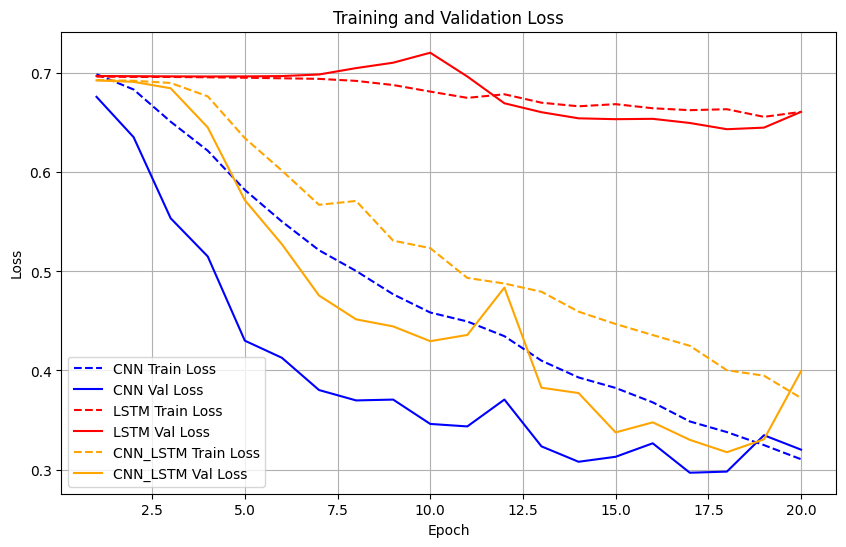

In [20]:
# Plot Training and Validation Loss Over Epochs
plt.figure(figsize=(10, 6))
for model in models:
    subset = metrics_df[metrics_df["model"] == model]
    plt.plot(subset["epoch"], subset["train_loss"], label=f"{model} Train Loss", linestyle="--", color=color_map[model])
    plt.plot(subset["epoch"], subset["val_loss"], label=f"{model} Val Loss",color=color_map[model])
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.legend()
plt.grid()
plt.show()


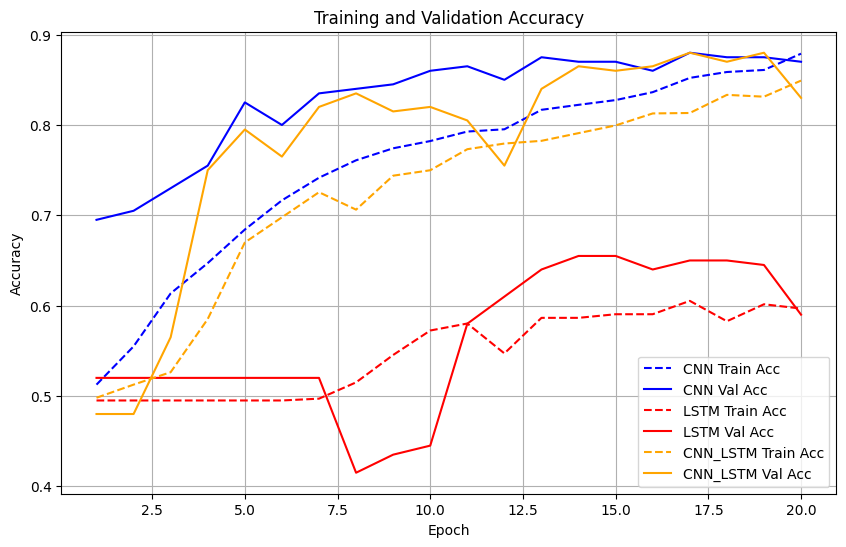

In [21]:
# Plot Training and Validation Accuracy
plt.figure(figsize=(10, 6))
for model in models:
    subset = metrics_df[metrics_df["model"] == model]
    plt.plot(subset["epoch"], subset["train_acc"], label=f"{model} Train Acc", linestyle="--", color=color_map[model])
    plt.plot(subset["epoch"], subset["val_acc"], label=f"{model} Val Acc", color=color_map[model])
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training and Validation Accuracy")
plt.legend()
plt.grid()
plt.show()


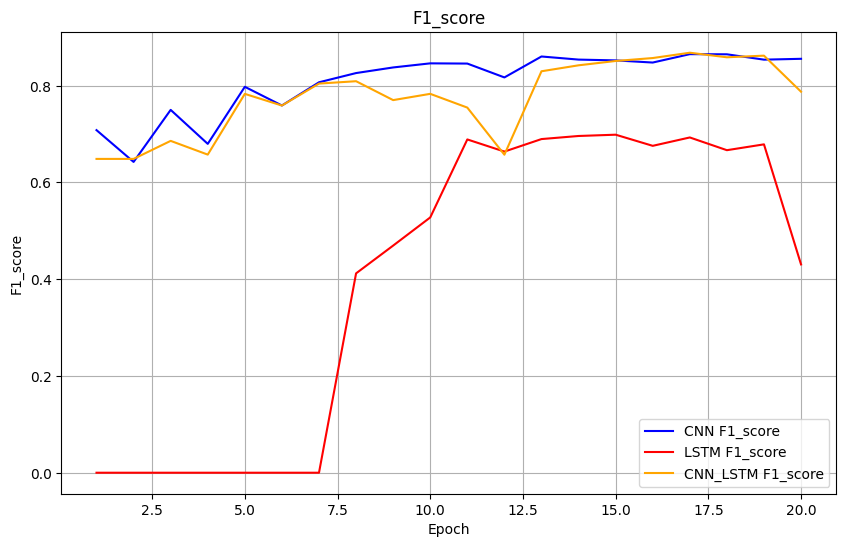

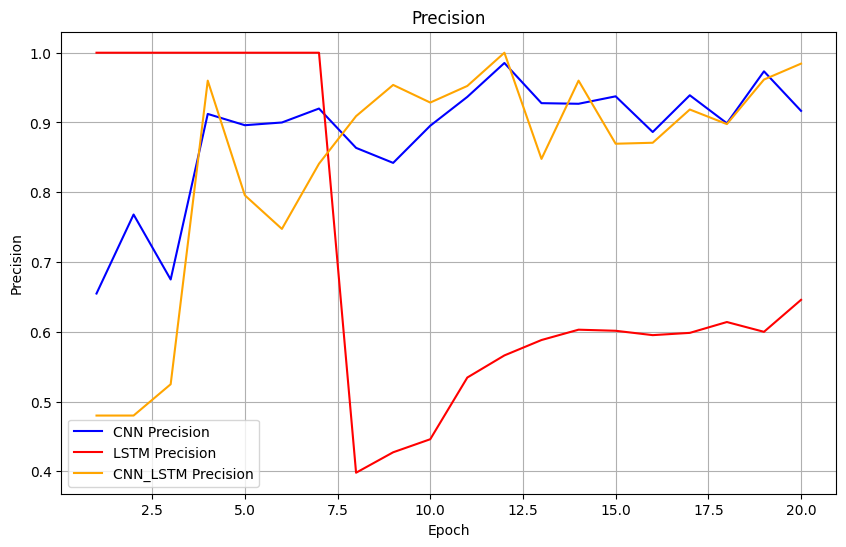

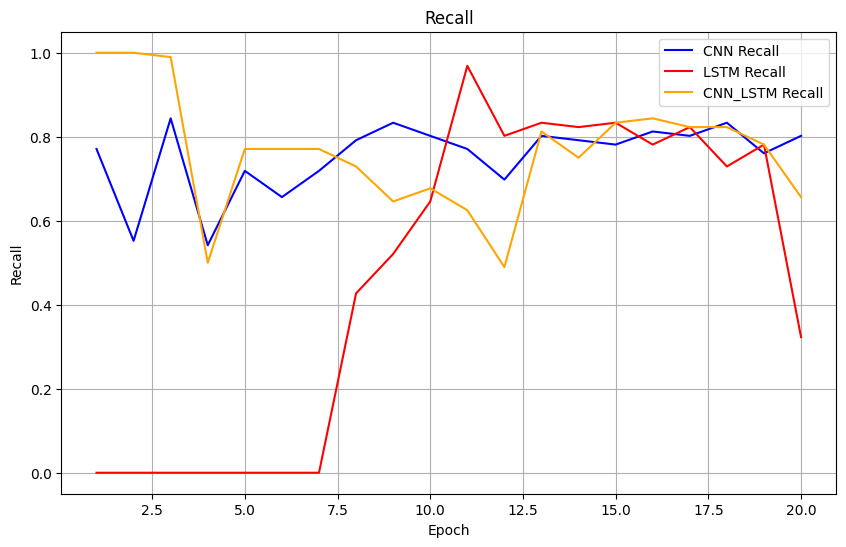

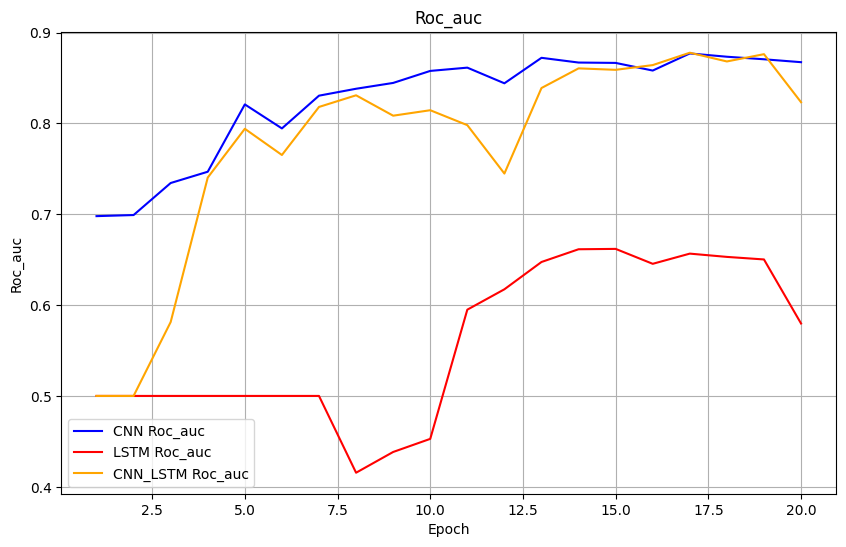

In [22]:
# Plot F1 Score, Precision, Recall, and ROC-AUC
metrics_to_plot = ["f1_score", "precision", "recall", "roc_auc"]
for metric in metrics_to_plot:
    plt.figure(figsize=(10, 6))
    for model in models:
        subset = metrics_df[metrics_df["model"] == model]
        plt.plot(subset["epoch"], subset[metric], label=f"{model} {metric.capitalize()}",color=color_map[model])
    plt.xlabel("Epoch")
    plt.ylabel(metric.capitalize())
    plt.title(f"{metric.capitalize()}")
    plt.legend()
    plt.grid()
    plt.show()
    